In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

RESULTS_DIR = Path('../results')
METRICS_CSV = RESULTS_DIR / 'metrics.csv'
VIS_DIR     = RESULTS_DIR / 'visualisations'

## Training summary

In [2]:
df = pd.read_csv(METRICS_CSV)

best = df.loc[df['val_dice'].idxmax()]
print(f"Epochs trained  : {len(df)}")
print(f"Best val Dice   : {best['val_dice']:.4f}  (epoch {int(best['epoch'])})")
print(f"Best val HD95   : {best['val_hd95']:.2f} mm")
print(f"Final train loss: {df['train_loss'].iloc[-1]:.4f}")
df.tail()

Epochs trained  : 200
Best val Dice   : 0.9886  (epoch 189)
Best val HD95   : 0.00 mm
Final train loss: 0.0122


,epoch,train_loss,val_dice,val_hd95,lr
195,196,0.029837,0.9885,0.0,0.000002
196,197,0.026649,0.9885,0.0,0.000002
197,198,0.017133,0.9885,0.0,0.000001
198,199,0.027280,0.9885,0.0,0.000001
199,200,0.012161,0.9886,0.0,0.000001


## Learning curves

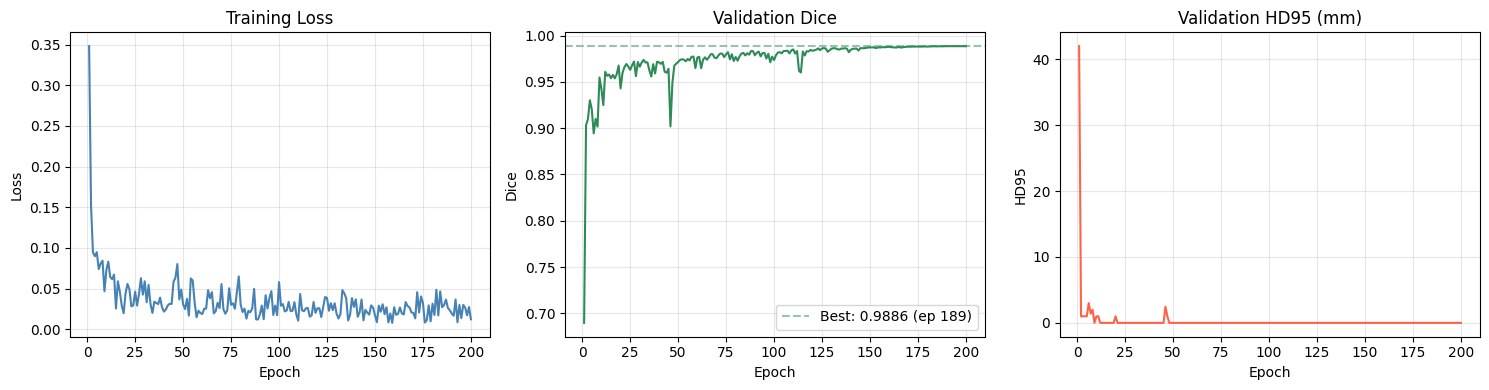

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['epoch'], df['train_loss'], color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['val_dice'], color='seagreen')
axes[1].axhline(best['val_dice'], color='seagreen', linestyle='--', alpha=0.5,
                label=f"Best: {best['val_dice']:.4f} (ep {int(best['epoch'])})")
axes[1].set_title('Validation Dice')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['epoch'], df['val_hd95'], color='tomato')
axes[2].set_title('Validation HD95 (mm)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('HD95')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Segmentation visualisations

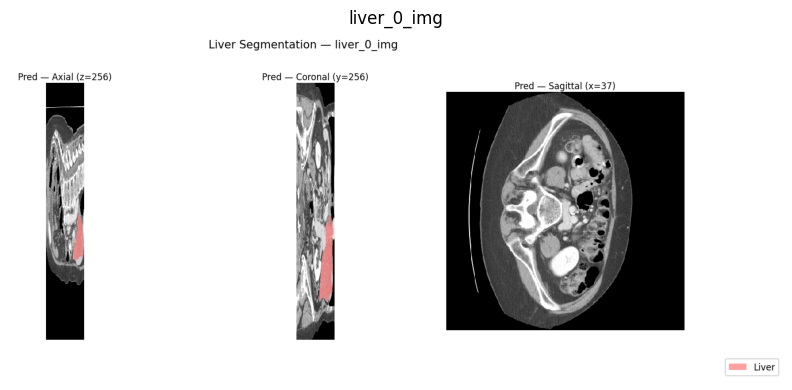

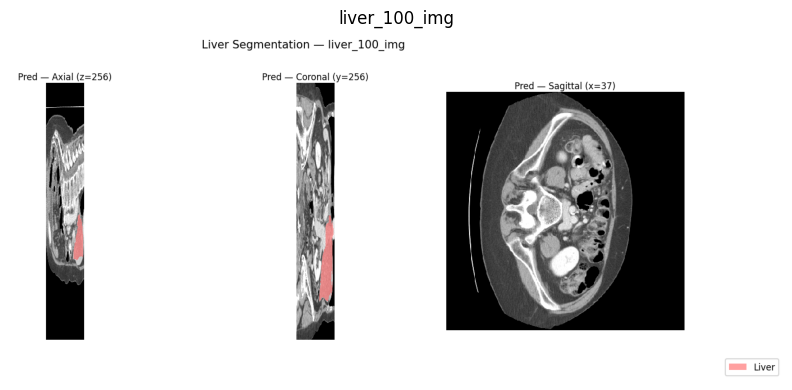

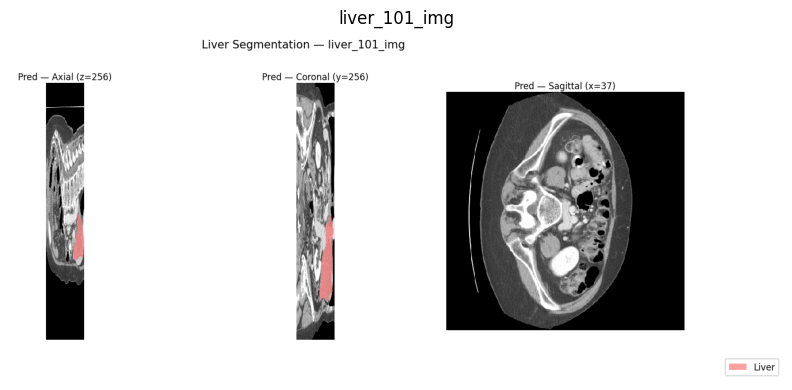

In [4]:
png_files = sorted(VIS_DIR.glob('*.png'))

for png in png_files:
    img = mpimg.imread(png)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.imshow(img)
    ax.set_title(png.stem, fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()